<a href="https://colab.research.google.com/github/Naavyakannan/EEG_GA/blob/main/EEG_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# home environment
import pandas as pd
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import numpy as np
import pywt
from PyEMD import EMD

In [ ]:
pip install PyEMD

In [ ]:
pip install EMD-signal

In [ ]:
file_path = "DDatasetsamp - Sheet1.csv"
data = pd.read_csv(file_path)

In [ ]:
data.head()

,theta_band,alpha_band,low_beta_band,high_beta_band,gamma_band,arousal,valence,dominance,linking
0,613.663621,914.264525,581.107620,1325.822606,1289.397695,7.71,7.6,6.9,7.83
1,839.213721,1020.221809,793.121658,1395.900243,1342.071643,7.71,7.6,6.9,7.83
2,890.226769,872.670620,649.000277,1160.705207,1055.468213,7.71,7.6,6.9,7.83
3,468.742832,767.808561,652.336315,909.577165,940.761742,7.71,7.6,6.9,7.83
4,754.402536,1432.087822,741.796243,1302.844506,974.411370,7.71,7.6,6.9,7.83


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   theta_band      499 non-null    float64
 1   alpha_band      499 non-null    float64
 2   low_beta_band   499 non-null    float64
 3   high_beta_band  499 non-null    float64
 4   gamma_band      499 non-null    float64
 5   arousal         499 non-null    float64
 6   valence         499 non-null    float64
 7   dominance       499 non-null    float64
 8   linking         499 non-null    float64
dtypes: float64(9)
memory usage: 35.2 KB


In [ ]:
data["arousal"] = pd.to_numeric(data["arousal"], errors='coerce')
data["valence"] = pd.to_numeric(data["valence"], errors='coerce')
data = data.dropna(subset=["arousal", "valence"])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   theta_band      499 non-null    float64
 1   alpha_band      499 non-null    float64
 2   low_beta_band   499 non-null    float64
 3   high_beta_band  499 non-null    float64
 4   gamma_band      499 non-null    float64
 5   arousal         499 non-null    float64
 6   valence         499 non-null    float64
 7   dominance       499 non-null    float64
 8   linking         499 non-null    float64
dtypes: float64(9)
memory usage: 35.2 KB


In [ ]:
# data['label'] = 'Relaxed'
# data.loc[(data["arousal"] >= 0) & (data["valence"] > 0), 'label'] = 'Happy'
# data.loc[(data["arousal"] > 0) & (data["valence"] <= 0), 'label'] = 'Angry'
# data.loc[(data["arousal"] <= 0) & (data["valence"] < 0), 'label'] = 'Sad'

In [ ]:
# category_counts = data['label'].value_counts()
# plt.figure(figsize=(4, 4))
# plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
# plt.title('Pie Chart of output labels')
# plt.show()

In [ ]:
data.tail()

,theta_band,alpha_band,low_beta_band,high_beta_band,gamma_band,arousal,valence,dominance,linking
494,776.295127,821.566261,1245.436198,2458.146253,1336.488075,4.94,6.01,6.12,8.06
495,838.553484,913.480145,717.458227,920.448515,1336.504430,4.94,6.01,6.12,8.06
496,1310.185956,1117.490178,850.295892,606.526246,1336.520786,4.94,6.01,6.12,8.06
497,1201.246555,1115.532868,836.859347,630.500779,1336.226383,4.94,6.01,6.12,8.06
498,3988.754954,3346.729817,1495.655683,5709.223602,1336.553497,4.94,6.01,6.12,8.06


In [ ]:
print("Data Statistics:")
data.describe()

Data Statistics:


,theta_band,alpha_band,low_beta_band,high_beta_band,gamma_band,arousal,valence,dominance,linking
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,1411.025193,1373.697358,1114.527321,1413.042354,1398.554007,5.292926,5.747014,6.020802,6.912505
std,3295.126328,2364.928707,2511.922317,1250.258398,547.245572,2.503206,2.131175,2.044444,1.185430
min,416.877339,397.864805,308.437506,591.031792,773.127821,1.360000,2.080000,2.040000,3.870000
25%,780.369326,770.826415,594.905000,1003.030775,1127.968670,2.900000,3.350000,3.620000,6.150000
50%,975.305458,1001.809357,722.857998,1163.936012,1304.331600,4.940000,6.920000,6.900000,7.090000
75%,1302.820090,1309.897150,947.083240,1408.559924,1474.918148,7.440000,7.440000,7.370000,7.900000
max,58696.709850,31676.352620,40030.053270,17461.129960,6190.228392,9.000000,8.150000,9.000000,8.470000


In [ ]:
print("Data Information:")
data.info()

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   theta_band      499 non-null    float64
 1   alpha_band      499 non-null    float64
 2   low_beta_band   499 non-null    float64
 3   high_beta_band  499 non-null    float64
 4   gamma_band      499 non-null    float64
 5   arousal         499 non-null    float64
 6   valence         499 non-null    float64
 7   dominance       499 non-null    float64
 8   linking         499 non-null    float64
dtypes: float64(9)
memory usage: 35.2 KB


## Preprocessing

In [ ]:
eeg_data = data.iloc[:, :5].values

n_components = 5
ica = FastICA(n_components=n_components, random_state=97, max_iter=800)
components = ica.fit_transform(eeg_data)

/usr/local/lib/python3.10/dist-packages/sklearn/decomposition/_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


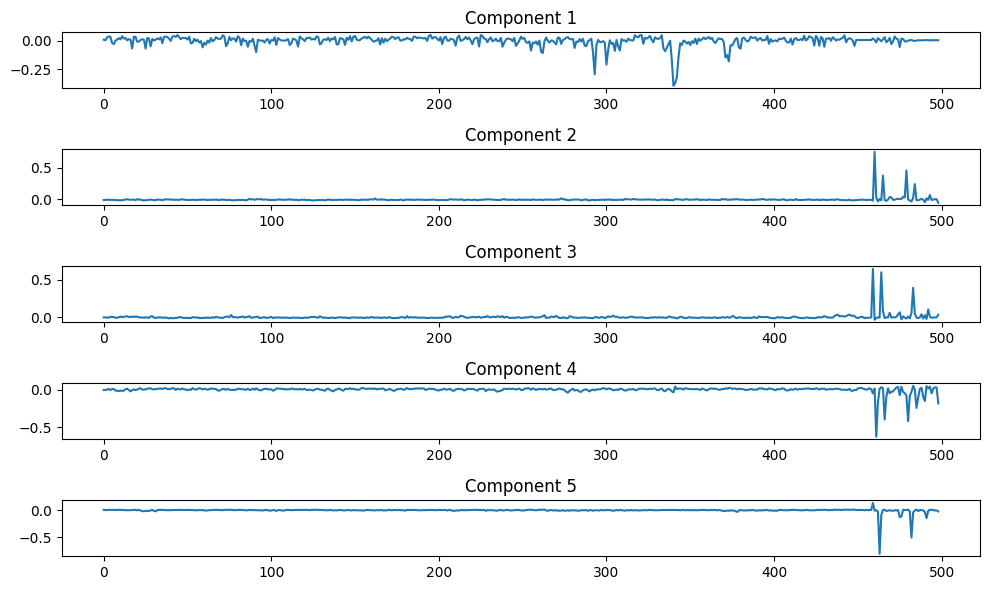

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(n_components):
    plt.subplot(n_components, 1, i + 1)
    plt.plot(components[:, i])
    plt.title(f'Component {i+1}')
plt.tight_layout()
plt.show()

## Augmentation

In [ ]:
#Gaussian Noise Injection
noise_level = 0.1
eeg_data_noisy = components + noise_level * np.random.randn(*components.shape)

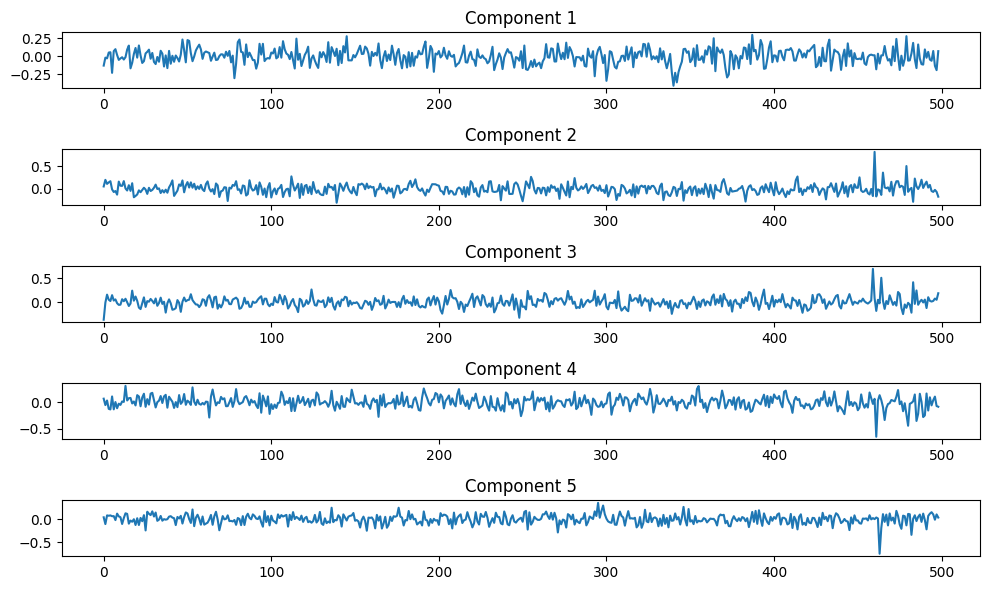

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(n_components):
    plt.subplot(n_components, 1, i + 1)
    plt.plot(eeg_data_noisy[:, i])
    plt.title(f'Component {i+1}')
plt.tight_layout()
plt.show()

In [ ]:
#Time Wrapping
def time_warp(data, factor=1.1):
    num_points = data.shape[0]
    indices = np.arange(num_points) * factor
    indices = np.clip(indices, 0, num_points - 1).astype(int)
    warped_data = np.interp(np.arange(num_points), indices, data)
    return warped_data

eeg_data_warped = np.apply_along_axis(time_warp, axis=1, arr=components)

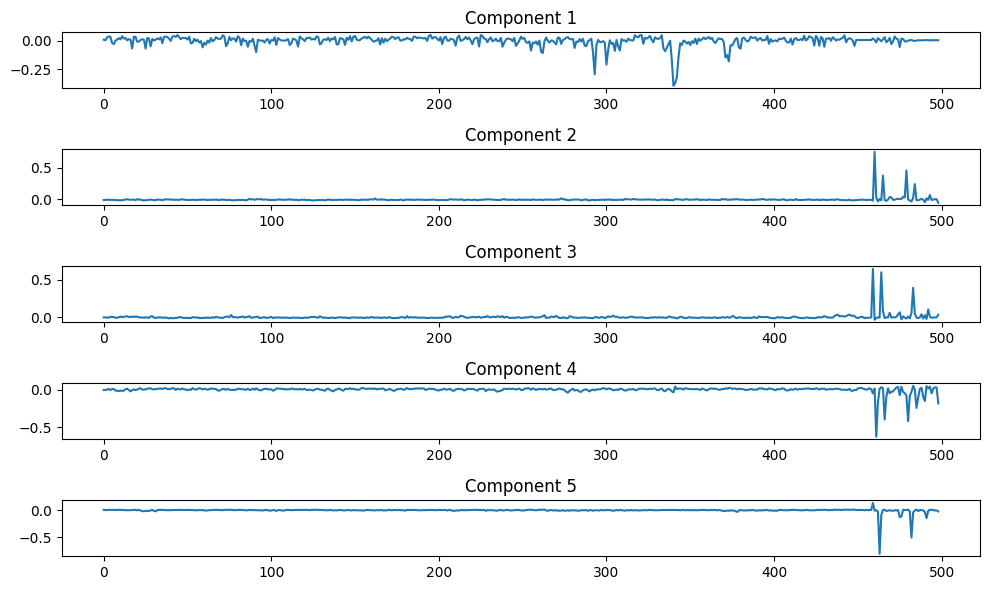

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(n_components):
    plt.subplot(n_components, 1, i + 1)
    plt.plot(eeg_data_warped[:, i])
    plt.title(f'Component {i+1}')
plt.tight_layout()
plt.show()

In [ ]:
combined_data = np.concatenate([eeg_data, eeg_data_noisy, eeg_data_warped], axis=0)

In [ ]:
np.shape(combined_data)

(1497, 5)

# Defining Models

In [ ]:
from keras.models import Sequential
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.layers import Dense , Dropout, Input
import tensorflow as tf
from tensorflow.keras.models import Model

In [ ]:
def cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Conv1D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Conv1D(64, 3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Flatten()(x)
    x = Dense(96, activation='relu')(x)
    x = Dropout(0.40)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.40)(x)
    outputs = Dense(4, activation='linear')(x)  # Use 'softmax' for classification tasks

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

In [ ]:
from keras.layers import SimpleRNN

def build_rnn_model(input_shape):
    inputs = Input(shape=input_shape)

    x = SimpleRNN(units=50, activation='relu')(inputs)
    outputs = Dense(4, activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

In [ ]:
from keras.layers import LSTM

def build_lstm_model(features):
    inputs = Input(shape=(features,1))
    #inputs = Input(batch_shape=(1, 1, features))

    x = LSTM(4)(inputs)
    x = Flatten()(x)
    outputs = Dense(4, activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

## Feature Extraction

In [ ]:
#Wavelet Transform

In [ ]:
def extract_wavelet_features(signal, wavelet='db4', level=5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    features = []
    for c in coeffs:
        features.extend([np.mean(c), np.std(c), np.median(c), np.max(c), np.min(c)])
    return features

In [ ]:
wavelet_features = [extract_wavelet_features(signal) for signal in combined_data]

/usr/local/lib/python3.10/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


In [ ]:
wavelet_features=pd.DataFrame(wavelet_features)

In [ ]:
np.shape(wavelet_features)

(1497, 30)

In [ ]:
y=list(data.iloc[:,5:].values)
y=y*3

In [ ]:
label=np.asarray(y)
feat  = np.asarray(wavelet_features)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(feat, label, test_size=0.2, random_state=42)

## Feature Selection

In [ ]:
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from tqdm import tqdm

In [ ]:
#Genetic Algorithm
def evaluate_individual(individual, X, y):
    selected_X = X[:, individual]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    model = Sequential()
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse

def initialize_population(pop_size, num_features):
    population = []
    for _ in range(pop_size):
        individual = np.random.choice([0, 1], size=num_features)
        population.append(individual)
    return population

def select_parents(population, scores, num_parents):
    parents = []
    for _ in range(num_parents):
        max_index = np.argmin(scores)
        parents.append(population[max_index])
        scores[max_index] = float('inf')  # Set to infinity so it won't be selected again
    return parents

def crossover(parents, num_offsprings):
    offsprings = []
    for _ in range(num_offsprings):
        idx = np.random.choice(len(parents), size=2, replace=False)
        parent1=parents[idx[0]]
        parent2=parents[idx[1]]
        crossover_point = np.random.randint(0, len(parent1))
        offspring = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
        offsprings.append(offspring)
    return offsprings

def mutate(offsprings, mutation_rate):
    mutated_offsprings = []
    for offspring in offsprings:
        if np.random.rand() < mutation_rate:
            mutation_point = np.random.randint(0, len(offspring))
            offspring[mutation_point] = 1 - offspring[mutation_point]
        mutated_offsprings.append(offspring)
    return mutated_offsprings

population_size = 50
num_generations = 10
num_parents = 10
num_offsprings = population_size - num_parents
mutation_rate = 0.1

population = initialize_population(population_size, X_train.shape[1])

for generation in tqdm(range(num_generations)):

    scores = [evaluate_individual(individual, X_train, y_train) for individual in population]

    parents = select_parents(population, scores, num_parents)

    offsprings = crossover(parents, num_offsprings)

    mutated_offsprings = mutate(offsprings, mutation_rate)

    population = parents + mutated_offsprings

best_individual = population[np.argmin(scores)]

100%|██████████| 10/10 [22:27<00:00, 134.72s/it]


In [ ]:
best_individual

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1])

In [ ]:
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from tqdm import tqdm

def objective(features, X_train, y_train, X_test, y_test):
    selected_X_train = X_train[:, features.astype(bool)]
    selected_X_test = X_test[:, features.astype(bool)]


    model = Sequential()
    model.add(Dense(5, input_dim=selected_X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')

    model.fit(selected_X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(selected_X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse
def firefly_algorithm(X_train, y_train, X_test, y_test, num_fireflies, max_generation, num_features):

    fireflies = np.random.rand(num_fireflies, num_features)
    best_firefly = None
    best_mse = float('inf')

    for generation in tqdm(range(max_generation)):
        for i in range(num_fireflies):
            mse = objective(fireflies[i], X_train, y_train, X_test, y_test)
            if mse < best_mse:
                best_firefly = fireflies[i].copy()
                best_mse = mse

        for i in range(num_fireflies):
            for j in range(num_fireflies):
                if objective(fireflies[j], X_train, y_train, X_test, y_test) < objective(fireflies[i], X_train, y_train, X_test, y_test):
                    beta = 1
                    distance = np.linalg.norm(fireflies[i] - fireflies[j])
                    fireflies[i] += beta * (fireflies[j] - fireflies[i]) / (1 + distance)

        fireflies = np.clip(fireflies, 0, 1)

    return best_firefly
best_features = firefly_algorithm(X_train, y_train, X_test, y_test, num_fireflies=20, max_generation=2, num_features=30)

  0%|          | 0/2 [00:00<?, ?it/s]


IndexError: boolean index did not match indexed array along dimension 1; dimension is 5 but corresponding boolean dimension is 30

In [ ]:
print(best_features)

In [ ]:
def eval_individual(features, X, y):
    if np.sum(features) == 0:
        return float('inf')

    selected_X = X[:, features.astype(bool)]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    selected_X = X[:, features.astype(bool)]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    model = Sequential()
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse

def update_position(i, position, mse, iteration, max_iterations, positions, num_wolves,X,y):
    alpha = 0.1
    current_alpha = alpha * (1 - iteration / max_iterations)

    other_wolf = np.random.choice([x for x in range(num_wolves) if x != i])
    new_position = position + current_alpha * (positions[other_wolf] - position)
    #new_position = np.clip(new_position, 0, 1).astype(int)
    new_position = (new_position > 0.5).astype(int)

    mse1 = eval_individual(new_position, X, y)
    if mse1>mse:
        return position
    else:
        return new_position

def grey_wolf_optimizer(X, y, num_features, num_wolves, max_iterations):
    positions = np.random.randint(0, 2, size=(num_wolves, num_features))
    for iteration in tqdm(range(max_iterations)):
        for i in range(num_wolves):
            mse = eval_individual(positions[i], X, y)
            new_position = update_position(i, positions[i], mse, iteration, max_iterations, positions, num_wolves,X,y)
            positions[i] = new_position
    best_wolf = positions[np.argmin([eval_individual(position, X, y) for position in positions])]
    selected_features = np.where(best_wolf == 1)[0]
    print("Best wolf position:", best_wolf)
    return selected_features

num_features = 30
num_wolves = 10
max_iterations = 5

In [ ]:
selected_features = grey_wolf_optimizer(feat, label, num_features, num_wolves, max_iterations)

  0%|          | 0/5 [00:00<?, ?it/s]


IndexError: boolean index did not match indexed array along dimension 1; dimension is 5 but corresponding boolean dimension is 30

In [ ]:
selected_features

In [ ]:
# Select features based on GA
best_individual = np.array(best_individual)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=200

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = classifier.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()


history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = rnn_model.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
selected_X_test.shape

In [ ]:
y_pred.shape

In [ ]:
#LSTM Model

model_lstm = build_lstm_model( np.shape(selected_X)[1])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
base_models = [
    ('cnn', classifier),
    ('rnn', rnn_model),
    ('lstm', model_lstm)
]

In [ ]:
meta_regressor = LinearRegression()

stacking_regressor = StackingRegressor(estimators=base_models, final_estimator=meta_regressor)

multi_output_model = MultiOutputRegressor(stacking_regressor)
load_options = tf.saved_model.LoadOptions(experimental_io_device='/job:localhost')
h=multi_output_model.fit(selected_X, y_train, options=load_options)

y_pred = multi_output_model.predict(selected_X_test_lstm)

mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
# Select features based on firefly
best_individual = np.array(best_features)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=100

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()


history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#LSTM Model
model_lstm = build_lstm_model(1, 1, np.shape(selected_X)[1])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
# Select features based on greyWolf
best_individual = np.array(selected_features)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=100

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()


history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#LSTM Model
model_lstm = build_lstm_model(1, 1, np.shape(selected_X)[1])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

# Empirical Mode Decomposition (EMD)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(feat, label, test_size=0.2, random_state=42)

In [ ]:
def extract_imfs(signal):
    emd = EMD()
    imfs = emd(signal)
    res = np.mean(imfs, axis = 0)
    return res

imfs_data =[extract_imfs(signal) for signal in combined_data]
imfs_data=np.array(imfs_data)

In [ ]:
np.shape(imfs_data)

(1497, 5)

In [ ]:
imf_df=pd.DataFrame(imfs_data)

In [ ]:
# Data splitting

In [ ]:
y=list(data.iloc[:,5:].values)
y=y*3

In [ ]:
label=np.asarray(y)
feat  = np.asarray(imf_df)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(feat, label, test_size=0.2, random_state=42)

## Feature Selection

In [ ]:
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from tqdm import tqdm

In [ ]:
#Genetic Algorithm
def evaluate_individual(individual, X, y):
    selected_X = X[:, individual]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    model = Sequential()
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse

def initialize_population(pop_size, num_features):
    population = []
    for _ in range(pop_size):
        individual = np.random.choice([0, 1], size=num_features)
        population.append(individual)
    return population

def select_parents(population, scores, num_parents):
    parents = []
    for _ in range(num_parents):
        max_index = np.argmin(scores)
        parents.append(population[max_index])
        scores[max_index] = float('inf')  # Set to infinity so it won't be selected again
    return parents

def crossover(parents, num_offsprings):
    offsprings = []
    for _ in range(num_offsprings):
        idx = np.random.choice(len(parents), size=2, replace=False)
        parent1=parents[idx[0]]
        parent2=parents[idx[1]]
        crossover_point = np.random.randint(0, len(parent1))
        offspring = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
        offsprings.append(offspring)
    return offsprings

def mutate(offsprings, mutation_rate):
    mutated_offsprings = []
    for offspring in offsprings:
        if np.random.rand() < mutation_rate:
            mutation_point = np.random.randint(0, len(offspring))
            offspring[mutation_point] = 1 - offspring[mutation_point]
        mutated_offsprings.append(offspring)
    return mutated_offsprings

population_size = 50
num_generations = 25
num_parents = 10
num_offsprings = population_size - num_parents
mutation_rate = 0.1

population = initialize_population(population_size, X_train.shape[1])

for generation in tqdm(range(num_generations)):

    scores = [evaluate_individual(individual, X_train, y_train) for individual in population]

    parents = select_parents(population, scores, num_parents)

    offsprings = crossover(parents, num_offsprings)

    mutated_offsprings = mutate(offsprings, mutation_rate)

    population = parents + mutated_offsprings

best_individual = population[np.argmin(scores)]

In [ ]:
print(best_individual)

In [ ]:
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from tqdm import tqdm

def objective(features, X_train, y_train, X_test, y_test):
    selected_X_train = X_train[:, features.astype(bool)]
    selected_X_test = X_test[:, features.astype(bool)]


    model = Sequential()
    model.add(Dense(5, input_dim=selected_X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')

    model.fit(selected_X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(selected_X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse
def firefly_algorithm(X_train, y_train, X_test, y_test, num_fireflies, max_generation, num_features):

    fireflies = np.random.rand(num_fireflies, num_features)
    best_firefly = None
    best_mse = float('inf')

    for generation in tqdm(range(max_generation)):
        for i in range(num_fireflies):
            mse = objective(fireflies[i], X_train, y_train, X_test, y_test)
            if mse < best_mse:
                best_firefly = fireflies[i].copy()
                best_mse = mse

        for i in range(num_fireflies):
            for j in range(num_fireflies):
                if objective(fireflies[j], X_train, y_train, X_test, y_test) < objective(fireflies[i], X_train, y_train, X_test, y_test):
                    beta = 1
                    distance = np.linalg.norm(fireflies[i] - fireflies[j])
                    fireflies[i] += beta * (fireflies[j] - fireflies[i]) / (1 + distance)

        fireflies = np.clip(fireflies, 0, 1)

    return best_firefly
best_features = firefly_algorithm(X_train, y_train, X_test, y_test, num_fireflies=20, max_generation=50, num_features=5)

In [ ]:
print(best_features)

In [ ]:
def eval_individual(features, X, y):
    if np.sum(features) == 0:
        return float('inf')

    selected_X = X[:, features.astype(bool)]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    selected_X = X[:, features.astype(bool)]
    X_train, X_test, y_train, y_test = train_test_split(selected_X, y, test_size=0.2, random_state=42)

    model = Sequential()
    model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(4, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    y_pred = model.predict(X_test, verbose=0)
    mse = mean_squared_error(y_test, y_pred)

    return mse

def update_position(i, position, mse, iteration, max_iterations, positions, num_wolves,X,y):
    alpha = 0.1
    current_alpha = alpha * (1 - iteration / max_iterations)

    other_wolf = np.random.choice([x for x in range(num_wolves) if x != i])
    new_position = position + current_alpha * (positions[other_wolf] - position)
    #new_position = np.clip(new_position, 0, 1).astype(int)
    new_position = (new_position > 0.5).astype(int)

    mse1 = eval_individual(new_position, X, y)
    if mse1>mse:
        return position
    else:
        return new_position

def grey_wolf_optimizer(X, y, num_features, num_wolves, max_iterations):
    positions = np.random.randint(0, 2, size=(num_wolves, num_features))
    for iteration in tqdm(range(max_iterations)):
        for i in range(num_wolves):
            mse = eval_individual(positions[i], X, y)
            new_position = update_position(i, positions[i], mse, iteration, max_iterations, positions, num_wolves,X,y)
            positions[i] = new_position
    best_wolf = positions[np.argmin([eval_individual(position, X, y) for position in positions])]
    selected_features = np.where(best_wolf == 1)[0]
    print("Best wolf position:", best_wolf)
    return selected_features

num_features = 5
num_wolves = 10
max_iterations = 10

In [ ]:
selected_features = grey_wolf_optimizer(feat, label, num_features, num_wolves, max_iterations)

In [ ]:
selected_features

In [ ]:
# Select features based on GA
best_individual = np.array(best_individual)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=100

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()


history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#LSTM Model
model_lstm = build_lstm_model(1, 1, np.shape(selected_X)[1])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
# Select features based on firefly
best_individual = np.array(best_features)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=100

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()


history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#LSTM Model
model_lstm = build_lstm_model(1, 1, np.shape(best_individual)[0])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
# Select features based on greyWolf
best_individual = np.array(selected_features)
keep_columns = best_individual.astype(bool)

selected_X = X_train[:, keep_columns]
selected_X_test = X_test[:, keep_columns]
selected_X = np.expand_dims(selected_X,axis=-1)
selected_X_test = np.expand_dims(selected_X_test,axis=-1)

#CNN Model
input_shape = (np.shape(selected_X)[1], 1)
classifier = cnn_model(input_shape)
classifier.summary()

EPOCHS=100

history=classifier.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#CNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#RNN Model
input_shape = (np.shape(selected_X)[1], 1)
rnn_model = build_rnn_model(input_shape)
rnn_model.summary()

history=rnn_model.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#RNN Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)

In [ ]:
#LSTM Model
model_lstm = build_lstm_model(1, 1,np.shape(selected_X)[1])
model_lstm.summary()

history=model_lstm.fit(x=selected_X,y=y_train,epochs=EPOCHS,validation_data=(selected_X_test,y_test))

In [ ]:
#LSTM Model evaluation
y_pred = model_lstm.predict(selected_X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("MSE for each target:", mse)